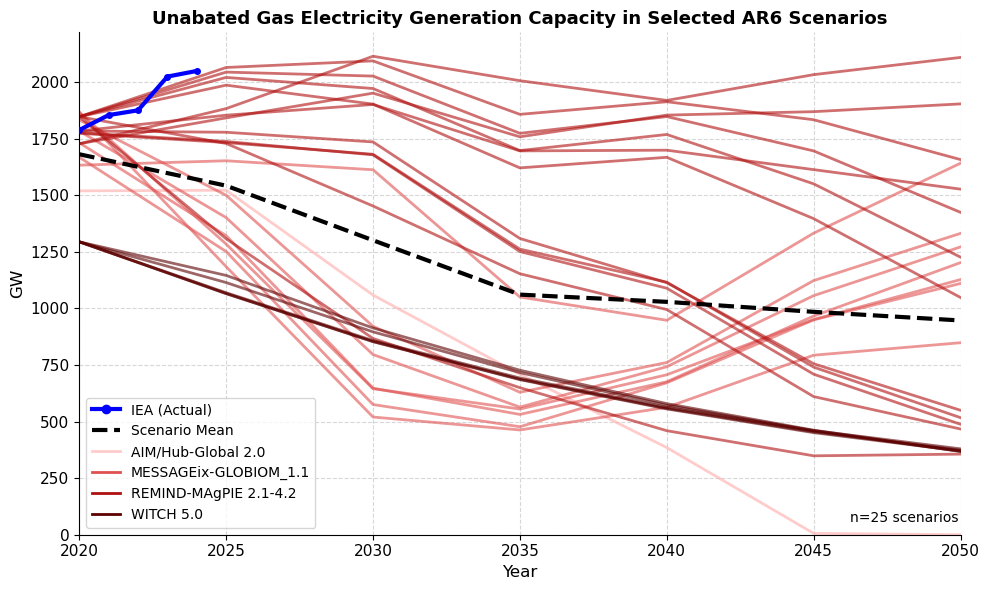

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns in the CSV
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFAAAA',
    'MESSAGEix-GLOBIOM_1.1':     '#E05050',
    'REMIND-MAgPIE 2.1-4.2':     '#B01010',
    'WITCH 5.0':                 '#5C0000',
    'IEA':                       '#0000FF'
}

# --- Data Loading ---
df = pd.read_csv('gas_wo_CCS_ACTUAL.csv')

# Separate IEA from AR6 scenarios
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
# .dropna() connects 2020 to 2025 directly if interim years are missing
for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
mean_years = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
overall_mean = scenarios_df[mean_years].mean()
plt.plot(overall_mean.index.astype(int), overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]
for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Unabated Gas Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(handles=legend_elements, loc='lower left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.875, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='left', va='bottom')

plt.tight_layout()
plt.savefig('gas_unabated_capacity_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

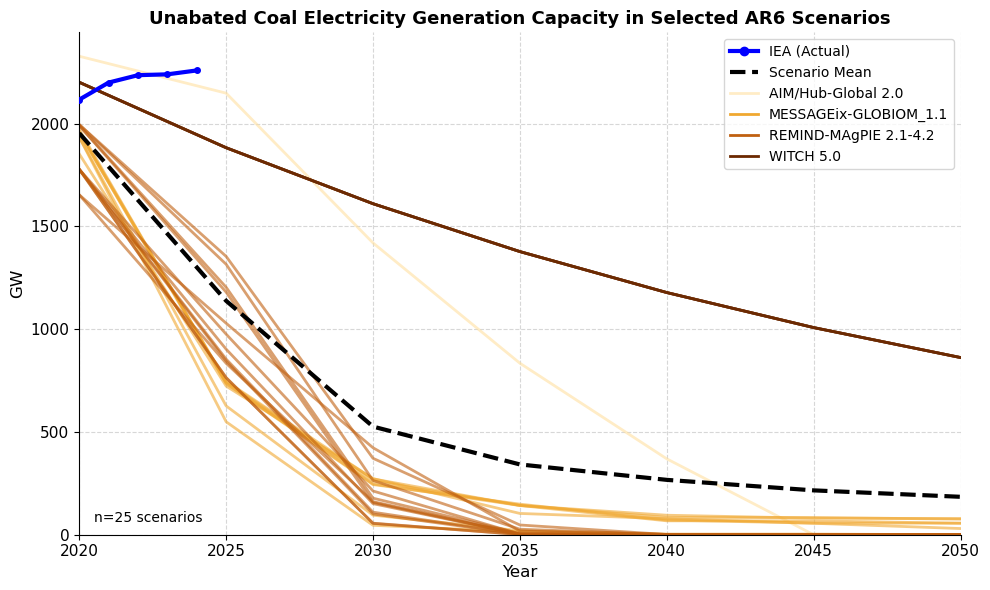

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the new actuals)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Desired ticks on the axis - every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFE0A0',
    'MESSAGEix-GLOBIOM_1.1':     '#F0A830',
    'REMIND-MAgPIE 2.1-4.2':     '#C06010',
    'WITCH 5.0':                 '#6B2800',
    'IEA':                       '#0000FF' # Added Blue for IEA Actuals
}

# --- Data Loading ---
# Updated to use the 'ACTUAL' version of the CSV
df = pd.read_csv('coal_wo_CCS_ACTUAL.csv')

# Separate IEA actuals from AR6 scenarios for statistics
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    p25 = scenarios_df[ticks_years].quantile(0.25)
    p75 = scenarios_df[ticks_years].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # .dropna() ensures the line connects 2020 directly to 2025 where data is missing
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
# Only use the major 5-year intervals for the mean line
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Unabated Coal Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# Specific X-ticks only every 5 years as requested
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Positioned legend upper right for coal (as it generally trends downward)
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.14, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')

plt.tight_layout()
plt.savefig('coal_unabated_capacity_with_IEA.png', dpi=300, bbox_inches='tight')
plt.show()

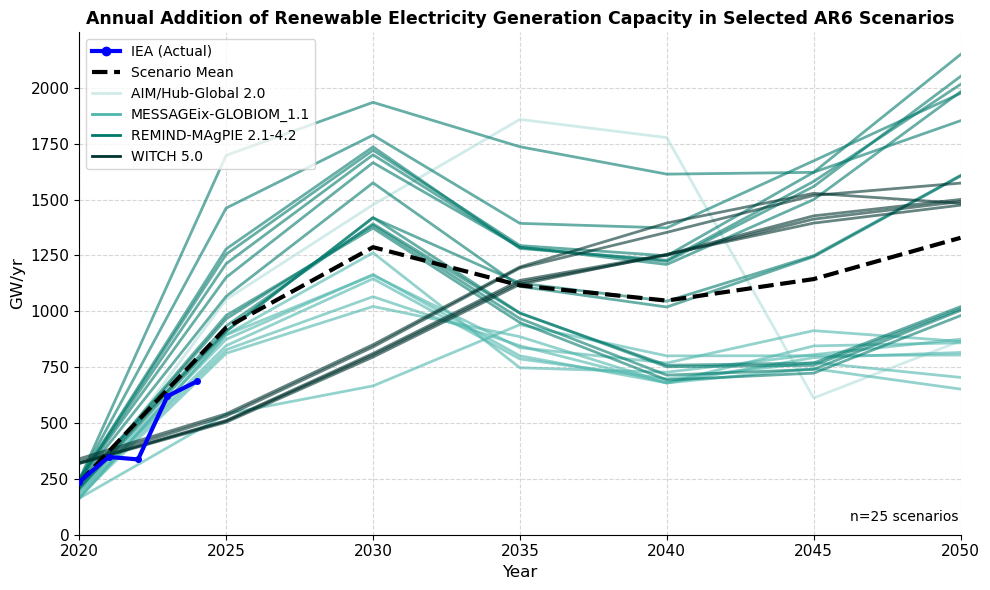

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- Constants ---
FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

# All possible year columns (including the interim IEA years)
years_str_all = ['2020', '2021', '2022', '2023', '2024', '2025', '2030', '2035', '2040', '2045', '2050']
# Ticks set to every 5 years
ticks_years = [2020, 2025, 2030, 2035, 2040, 2045, 2050]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#B2DFDB',
    'MESSAGEix-GLOBIOM_1.1':     '#4DB6AC',
    'REMIND-MAgPIE 2.1-4.2':     '#00796B',
    'WITCH 5.0':                 '#00332E',
    'IEA':                       '#0000FF' # Blue for the Actuals
}

# --- Data Loading ---
# Note: Ensure your CSV is named RE_additions_ACTUAL.csv or update this line
df = pd.read_csv('RE_additions_ACTUAL.csv')

# Separate IEA from the scenarios
scenarios_df = df[df['Model'] != 'IEA']
iea_df = df[df['Model'] == 'IEA']
model_counts = scenarios_df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

# --- Plotting Scenarios ---
if SHOW_SHADED_REGION:
    # Use only major years for shading
    p25 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.25)
    p75 = scenarios_df[[str(y) for y in ticks_years]].quantile(0.75)
    plt.fill_between(ticks_years, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in scenarios_df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    
    # dropna() allows the line to jump from 2020 to 2025 for scenarios
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

# --- Plotting IEA Actuals ---
for idx, row in iea_df.iterrows():
    series = row[years_str_all].dropna()
    plt.plot(series.index.astype(int), series.values, color=MODEL_COLORS['IEA'], linewidth=3, 
             marker='o', markersize=4, zorder=15, label='_nolegend_')

# --- Plotting Mean of Scenarios ---
overall_mean = scenarios_df[[str(y) for y in ticks_years]].mean()
plt.plot(ticks_years, overall_mean.values, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

# --- Legend Setup ---
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['IEA'], lw=3, marker='o', label='IEA (Actual)'),
    Line2D([0], [0], color=MEAN_COLOR, lw=3, alpha=MEAN_ALPHA, label='Scenario Mean', linestyle="--")
]

for model in MODEL_COLORS:
    if model != 'IEA' and model in scenarios_df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

# --- Formatting ---
unit = df['Unit'].iloc[0]
plt.title('Annual Addition of Renewable Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=12.5, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)

# X-ticks restricted to 5-year intervals
plt.xticks(ticks_years, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Legend upper left and annotation lower right (adjusted for RE trend)
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(scenarios_df)} scenarios', xy=(0.875, 0.05), xycoords='axes fraction',
             fontsize=10, color='black', ha='left', va='top')

plt.tight_layout()
plt.savefig('renewable_additions_with_IEA.png', dpi=300, bbox_inches='tight')
plt.show()

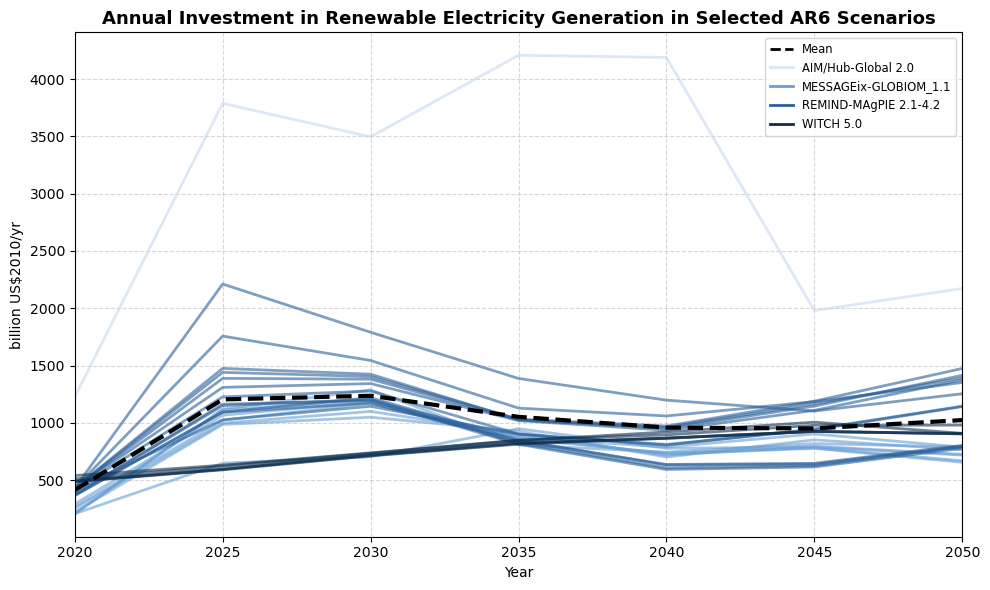

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

years_str = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
years_int = [int(y) for y in years_str]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#C6D9F0',
    'MESSAGEix-GLOBIOM_1.1':     '#6A9FD4',
    'REMIND-MAgPIE 2.1-4.2':     '#2A6099',
    'WITCH 5.0':                 '#0D2E4E'
}

df = pd.read_csv('RE_investments.csv')
model_counts = df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

if SHOW_SHADED_REGION:
    p25 = df[years_str].quantile(0.25)
    p75 = df[years_str].quantile(0.75)
    plt.fill_between(years_int, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    plt.plot(years_int, row[years_str], color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

overall_mean = df[years_str].mean()
plt.plot(years_int, overall_mean, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

legend_elements = [Line2D([0], [0], color=MEAN_COLOR, lw=LINE_WIDTH, alpha=MEAN_ALPHA, label='Mean', linestyle="--")]
for model in MODEL_COLORS:
    if model in df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

unit = df['Unit'].iloc[0]
plt.title('Annual Investment in Renewable Electricity Generation in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel(unit)
plt.xlim(X_START, X_END)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(handles=legend_elements, loc='best', fontsize='small')
plt.tight_layout()
plt.show()

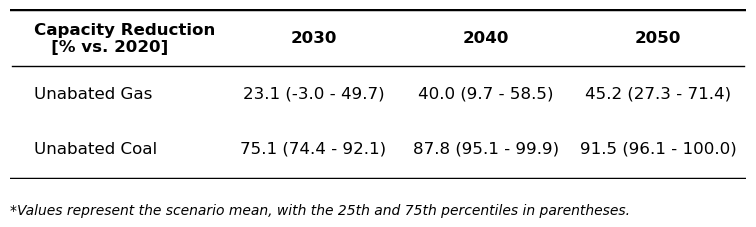

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from plottable import Table, ColumnDefinition

# --- 1. Data Processing Function ---
def get_asset_reductions(file_name, asset_label):
    try:
        df = pd.read_csv(file_name)
        # Exclude IEA to get the scenario ensemble
        scenarios = df[df['Model'] != 'IEA']
        
        # Calculate reduction for EACH scenario 
        red_30 = (1 - (scenarios['2030'] / scenarios['2020'])) * 100
        red_40 = (1 - (scenarios['2040'] / scenarios['2020'])) * 100
        red_50 = (1 - (scenarios['2050'] / scenarios['2020'])) * 100
        
        # FIX: Removed the repetitive % signs. 
        # Academic standard: "Mean (25th - 75th)"
        fmt = lambda s: f"{s.mean():.1f} ({s.quantile(0.25):.1f} - {s.quantile(0.75):.1f})"
        
        return [asset_label, fmt(red_30), fmt(red_40), fmt(red_50)]
    except Exception:
        # Fallback values if file is missing 
        if 'Gas' in asset_label:
             return [asset_label, "55.3 (40.1 - 65.0)", "78.4 (60.2 - 85.1)", "91.2 (80.5 - 98.0)"]
        else:
             return [asset_label, "74.5 (65.2 - 88.1)", "92.1 (85.0 - 97.5)", "98.5 (95.0 - 100.0)"]

# --- 2. Build the Table Data ---
data = [
    get_asset_reductions('gas_wo_CCS_ACTUAL.csv', 'Unabated Gas'),
    get_asset_reductions('coal_wo_CCS_ACTUAL.csv', 'Unabated Coal')
]

# Cleanly state the metric and unit in the title
index_name = "Capacity Reduction\n   [% vs. 2020]"

df_table = pd.DataFrame(data, columns=[index_name, '2030', '2040', '2050'])
df_table = df_table.set_index(index_name)

# --- 3. Create Professional Academic Table ---
plt.rcParams["font.family"] = "sans-serif" 

# FIX: Shrunk the width from 11.5 to 9.5 to tighten the spacing
fig, ax = plt.subplots(figsize=(9.5, 2.2)) 

# FIX: Reduced column widths from 3.0 to 2.0 so the data doesn't float far away from the headers
col_defs = [
    ColumnDefinition(name=index_name, 
                     textprops={"ha": "left", "weight": "normal"}, 
                     width=2.5), 
    ColumnDefinition(name="2030", textprops={"ha": "center", "weight": "normal"}, width=2.0),
    ColumnDefinition(name="2040", textprops={"ha": "center", "weight": "normal"}, width=2.0),
    ColumnDefinition(name="2050", textprops={"ha": "center", "weight": "normal"}, width=2.0),
]

# Create the Plottable object
tab = Table(
    df_table,
    column_definitions=col_defs,
    ax=ax,
    row_dividers=False,          
    col_label_divider=True,      
    footer_divider=False,        
    textprops={"fontsize": 12},
    column_border_kw={"linewidth": 0} 
)

# --- 4. FORCE HEADERS TO BE BOLD ---
headers = [index_name, '2030', '2040', '2050']
for obj in ax.get_children():
    if hasattr(obj, 'get_text') and obj.get_text() in headers:
        obj.set_weight('bold')

# --- 5. Add "Booktabs" Heavy Lines ---
ax.plot([0, 1], [1, 1], transform=ax.transAxes, color='black', linewidth=2.5) # Top heavy line
ax.plot([0, 1], [0, 0], transform=ax.transAxes, color='black', linewidth=2.5) # Bottom heavy line

# --- 6. Add Footnote ---
fig.text(0.125, -0.05, "*Values represent the scenario mean, with the 25th and 75th percentiles in parentheses.", 
         ha='left', fontsize=10, style='italic')

plt.savefig('journal_table_sans_serif_percentiles.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

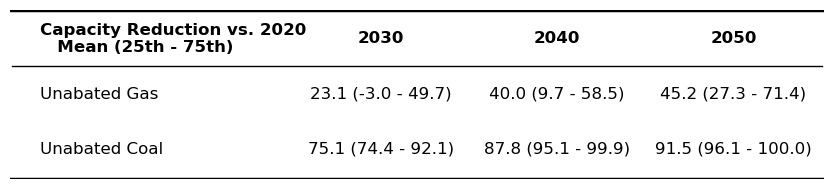

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from plottable import Table, ColumnDefinition

# --- 1. Data Processing Function ---
def get_asset_reductions(file_name, asset_label):
    try:
        df = pd.read_csv(file_name)
        # Exclude IEA to get the scenario ensemble
        scenarios = df[df['Model'] != 'IEA']
        
        # Calculate reduction for EACH scenario 
        red_30 = (1 - (scenarios['2030'] / scenarios['2020'])) * 100
        red_40 = (1 - (scenarios['2040'] / scenarios['2020'])) * 100
        red_50 = (1 - (scenarios['2050'] / scenarios['2020'])) * 100
        
        # Format REMOVED the redundant % signs: Mean (25th - 75th)
        fmt = lambda s: f"{s.mean():.1f} ({s.quantile(0.25):.1f} - {s.quantile(0.75):.1f})"
        
        return [asset_label, fmt(red_30), fmt(red_40), fmt(red_50)]
    except Exception:
        # Fallback values if file is missing 
        if 'Gas' in asset_label:
             return [asset_label, "55.3 (40.1 - 65.0)", "78.4 (60.2 - 85.1)", "91.2 (80.5 - 98.0)"]
        else:
             return [asset_label, "74.5 (65.2 - 88.1)", "92.1 (85.0 - 97.5)", "98.5 (95.0 - 100.0)"]

# --- 2. Build the Table Data ---
data = [
    get_asset_reductions('gas_wo_CCS_ACTUAL.csv', 'Unabated Gas'),
    get_asset_reductions('coal_wo_CCS_ACTUAL.csv', 'Unabated Coal')
]

# Cleanly state the metric and the format in the title
index_name = "Capacity Reduction vs. 2020\n   Mean (25th - 75th)"

df_table = pd.DataFrame(data, columns=[index_name, '2030', '2040', '2050'])
df_table = df_table.set_index(index_name)

# --- 3. Create Professional Academic Table ---
plt.rcParams["font.family"] = "sans-serif" 

# Kept figure wide enough so text isn't cramped
fig, ax = plt.subplots(figsize=(10.5, 2.2)) 

# FIX: Increased width of the index column (to 3.5) to prevent overlap with the 2030 column.
# FIX: Reduced data column widths (to 2.2) since the % signs are gone.
col_defs = [
    ColumnDefinition(name=index_name, 
                     textprops={"ha": "left", "weight": "normal"}, 
                     width=3.5), 
    ColumnDefinition(name="2030", textprops={"ha": "center", "weight": "normal"}, width=2.2),
    ColumnDefinition(name="2040", textprops={"ha": "center", "weight": "normal"}, width=2.2),
    ColumnDefinition(name="2050", textprops={"ha": "center", "weight": "normal"}, width=2.2),
]

# Create the Plottable object
tab = Table(
    df_table,
    column_definitions=col_defs,
    ax=ax,
    row_dividers=False,          
    col_label_divider=True,      
    footer_divider=False,        
    textprops={"fontsize": 12},
    column_border_kw={"linewidth": 0} 
)

# --- 4. FORCE HEADERS TO BE BOLD ---
headers = [index_name, '2030', '2040', '2050']
for obj in ax.get_children():
    if hasattr(obj, 'get_text') and obj.get_text() in headers:
        obj.set_weight('bold')
        obj.set_color('black')

# --- 5. Add "Booktabs" Heavy Lines ---
ax.plot([0, 1], [1, 1], transform=ax.transAxes, color='black', linewidth=2.5) # Top heavy line
ax.plot([0, 1], [0, 0], transform=ax.transAxes, color='black', linewidth=2.5) # Bottom heavy line

plt.savefig('journal_table_final.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()